## Week 3: Country Segmentation - Clustering, Classification & Ensemble Learning

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

try:
    from sklearn_extra.cluster import KMedoids
    HAS_KMEDOIDS = True
except ImportError:
    HAS_KMEDOIDS = False
    print('sklearn_extra not found — K-Medoids will be skipped')

# Preprocessing & evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score
)

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
print('All libraries loaded.')


sklearn_extra not found — K-Medoids will be skipped
All libraries loaded.


In [2]:
DATA_PATH = Path('Country-data.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Shape: {df_raw.shape}')
display(df_raw.head())


Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 2. Exploratory Data Analysis

We inspect the raw data for missing values, outliers, skewness, and feature relationships
before any transformation is applied.


### 2.1 Basic Info

In [3]:
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
numeric_cols = [c for c in df.columns if c != 'country']

print('=== Shape ===')
print(df.shape)
print('\n=== Dtypes ===')
display(df.dtypes.to_frame('dtype'))
print('\n=== Missing values ===')
display(df.isna().sum().to_frame('nulls'))
print('\n=== Duplicates:', df.duplicated().sum())


=== Shape ===
(167, 10)

=== Dtypes ===


,dtype
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64



=== Missing values ===


,nulls
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



=== Duplicates: 0


In [4]:
display(df.describe(include='all').T.round(2))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


### 2.2 Distributions — are features skewed?

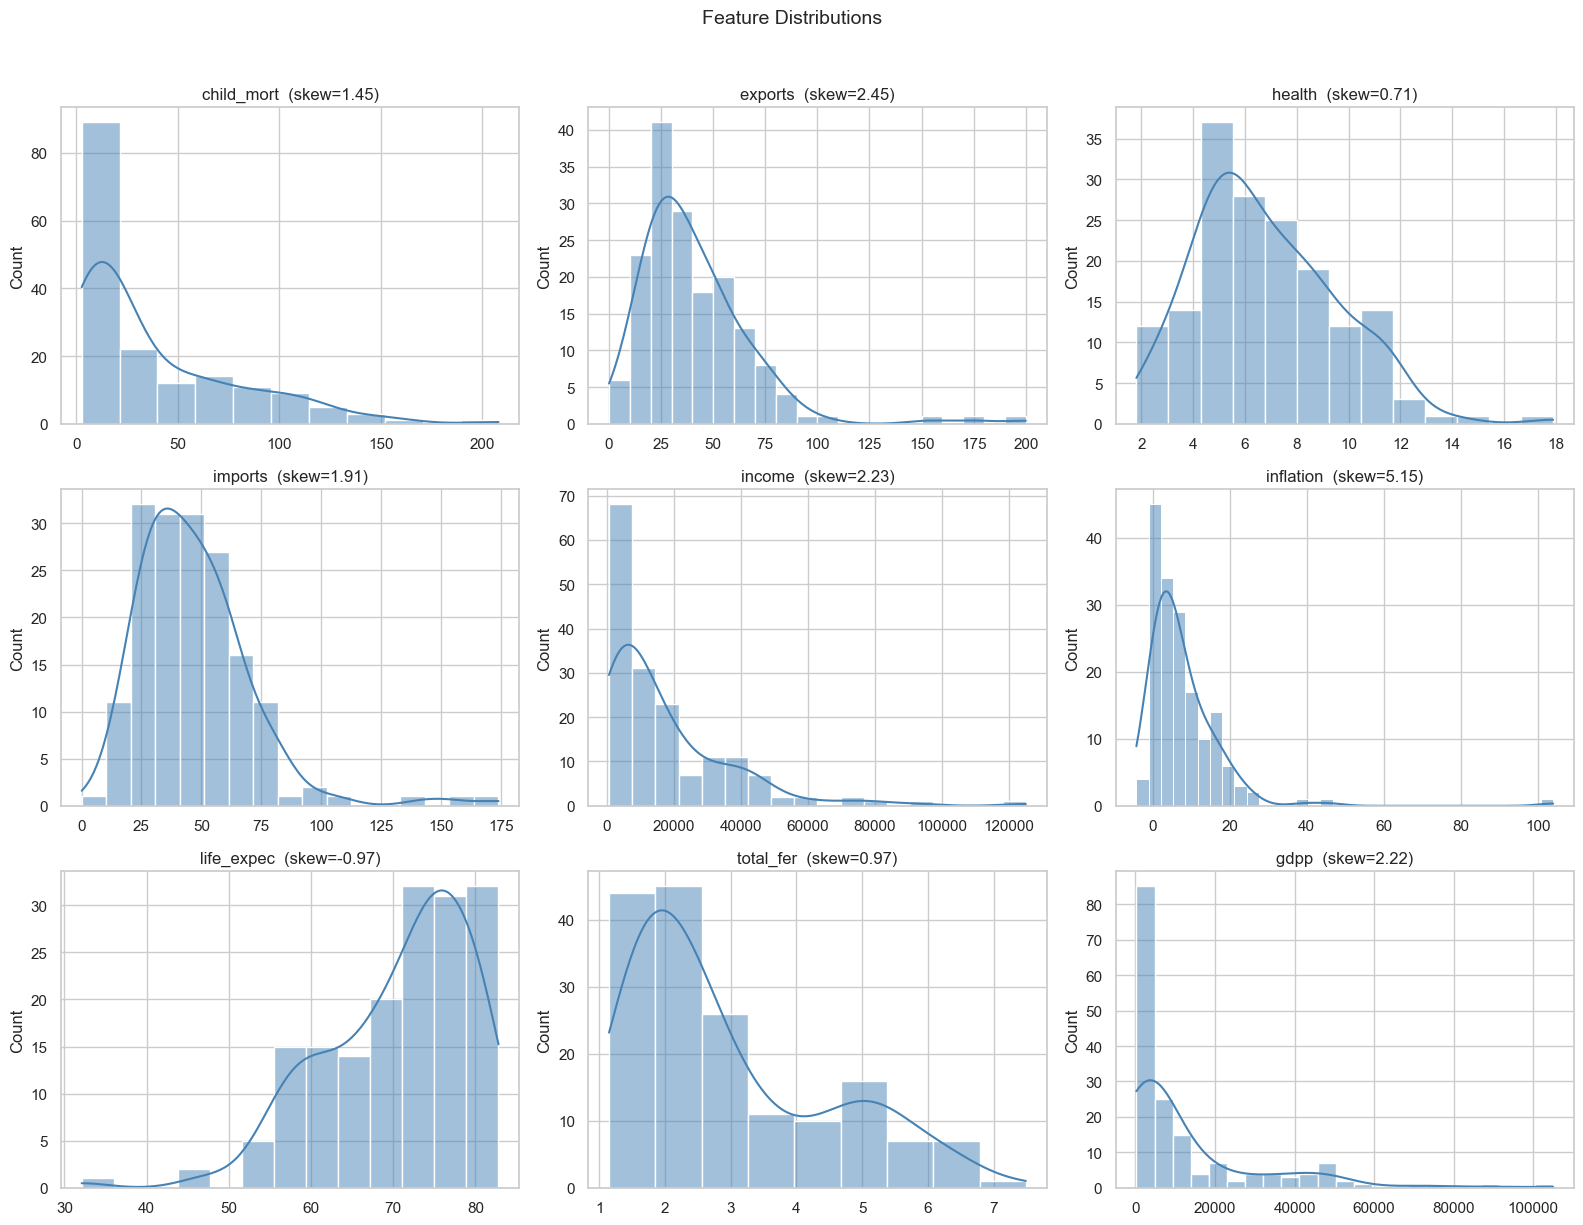

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    skew = df[col].skew()
    ax.set_title(f'{col}  (skew={skew:.2f})')
    ax.set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 2.3 Outlier Analysis

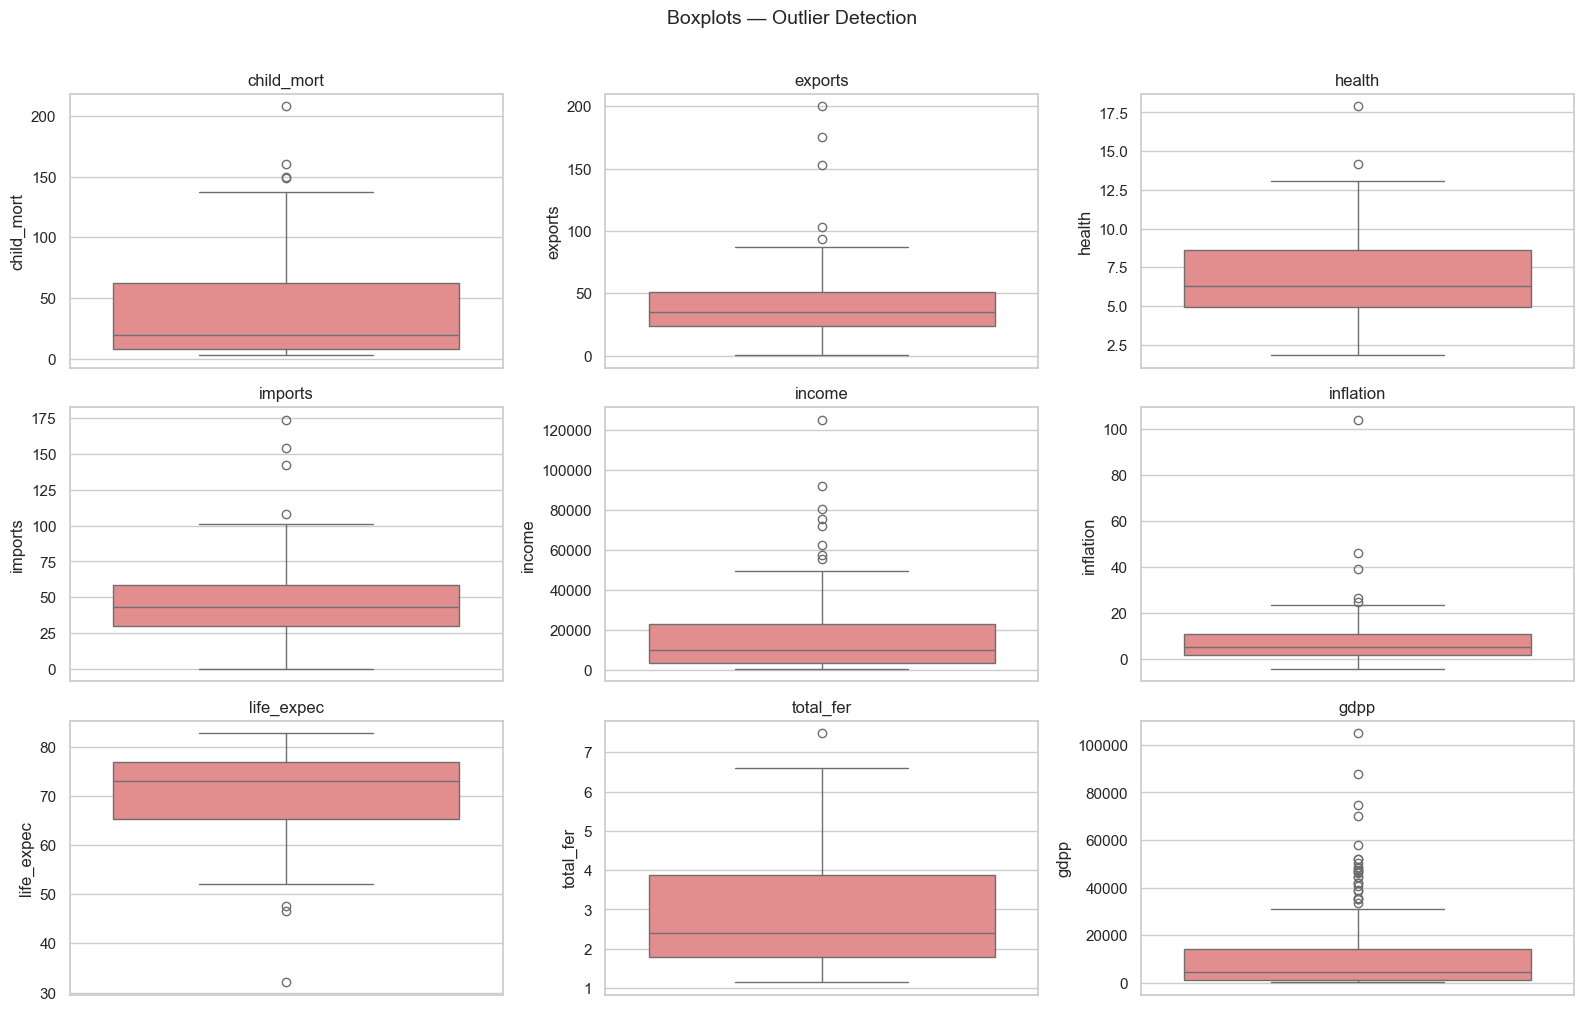

Outlier counts per feature (IQR method):


,outliers
gdpp,25
income,8
inflation,5
exports,5
child_mort,4
imports,4
life_expec,3
health,2
total_fer,1


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# IQR-based outlier counts
outlier_counts = {}
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_counts[col] = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
print('Outlier counts per feature (IQR method):')
display(pd.Series(outlier_counts).to_frame('outliers').sort_values('outliers', ascending=False))


### 2.4 Correlation Heatmap

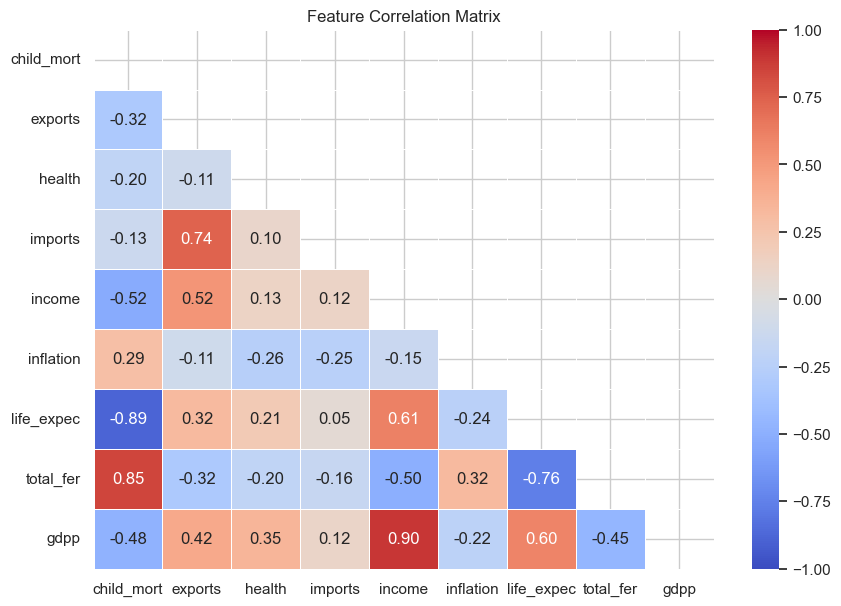

In [7]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()


### 2.5 Key Relationship Plots

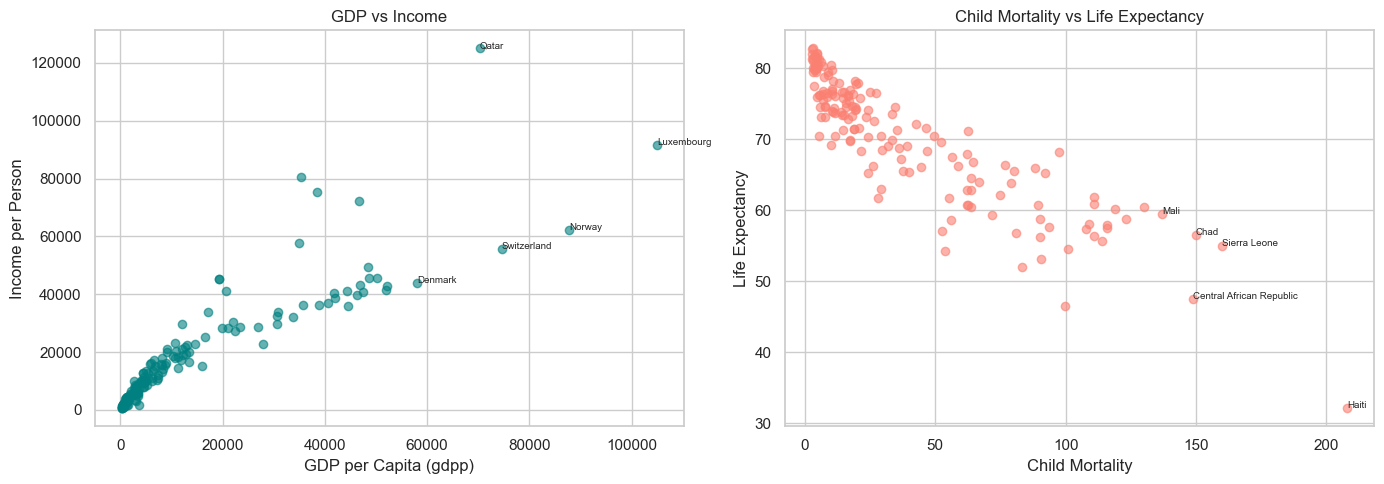

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GDP vs Income
axes[0].scatter(df['gdpp'], df['income'], alpha=0.6, color='teal')
axes[0].set_xlabel('GDP per Capita (gdpp)')
axes[0].set_ylabel('Income per Person')
axes[0].set_title('GDP vs Income')
for _, row in df.nlargest(5, 'gdpp').iterrows():
    axes[0].annotate(row['country'], (row['gdpp'], row['income']), fontsize=7)

# Child Mortality vs Life Expectancy
axes[1].scatter(df['child_mort'], df['life_expec'], alpha=0.6, color='salmon')
axes[1].set_xlabel('Child Mortality')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Child Mortality vs Life Expectancy')
for _, row in df.nlargest(5, 'child_mort').iterrows():
    axes[1].annotate(row['country'], (row['child_mort'], row['life_expec']), fontsize=7)

plt.tight_layout()
plt.show()


### 2.6 Country Extremes

In [9]:
print('=== Top 10 by GDP per Capita ===')
display(df.nlargest(10, 'gdpp')[['country', 'gdpp', 'income', 'life_expec', 'child_mort']].reset_index(drop=True))
print('\n=== Bottom 10 by GDP per Capita (likely aid-needed) ===')
display(df.nsmallest(10, 'gdpp')[['country', 'gdpp', 'income', 'life_expec', 'child_mort']].reset_index(drop=True))


=== Top 10 by GDP per Capita ===


,country,gdpp,income,life_expec,child_mort
0,Luxembourg,105000,91700,81.3,2.8
1,Norway,87800,62300,81.0,3.2
2,Switzerland,74600,55500,82.2,4.5
3,Qatar,70300,125000,79.5,9.0
4,Denmark,58000,44000,79.5,4.1
5,Sweden,52100,42900,81.5,3.0
6,Australia,51900,41400,82.0,4.8
7,Netherlands,50300,45500,80.7,4.5
8,Ireland,48700,45700,80.4,4.2
9,United States,48400,49400,78.7,7.3



=== Bottom 10 by GDP per Capita (likely aid-needed) ===


,country,gdpp,income,life_expec,child_mort
0,Burundi,231,764,57.7,93.6
1,Liberia,327,700,60.8,89.3
2,"Congo, Dem. Rep.",334,609,57.5,116.0
3,Niger,348,814,58.8,123.0
4,Sierra Leone,399,1220,55.0,160.0
5,Madagascar,413,1390,60.8,62.2
6,Mozambique,419,918,54.5,101.0
7,Central African Republic,446,888,47.5,149.0
8,Malawi,459,1030,53.1,90.5
9,Eritrea,482,1420,61.7,55.2


## 3. Feature Engineering

Several features are heavily right-skewed (`child_mort`, `income`, `gdpp`). Log-transforming them
improves clustering geometry and reduces the disproportionate influence of extreme values.

We also construct composite features to capture development-index-like signals.


In [10]:
df_fe = df.copy()

# --- 1. Log-transform skewed features (add 1 to handle any zeros) ---
for col in ['child_mort', 'income', 'gdpp', 'total_fer']:
    df_fe[f'{col}_log'] = np.log1p(df_fe[col])

# --- 2. Composite features ---
df_fe['trade_balance']    = df_fe['exports'] - df_fe['imports']
df_fe['health_intensity'] = df_fe['health'] / (df_fe['income_log'] + 1e-9)

# Composite development index (higher = more developed)
from sklearn.preprocessing import MinMaxScaler
_scaler = MinMaxScaler()
_norm = _scaler.fit_transform(df_fe[['gdpp_log', 'life_expec', 'child_mort_log']])
df_fe['dev_index'] = _norm[:, 0] * 0.4 + _norm[:, 1] * 0.4 - _norm[:, 2] * 0.2

print('New features added:', ['child_mort_log', 'income_log', 'gdpp_log', 'total_fer_log',
                               'trade_balance', 'health_intensity', 'dev_index'])
print('Dataset shape now:', df_fe.shape)
display(df_fe[['country','child_mort_log','income_log','gdpp_log',
                'trade_balance','health_intensity','dev_index']].head())


New features added: ['child_mort_log', 'income_log', 'gdpp_log', 'total_fer_log', 'trade_balance', 'health_intensity', 'dev_index']
Dataset shape now: (167, 17)


,country,child_mort_log,income_log,gdpp_log,trade_balance,health_intensity,dev_index
0,Afghanistan,4.513055,7.384610,6.317165,-34.9,1.026459,0.087912
1,Albania,2.867899,9.203416,8.316545,-20.6,0.711692,0.458292
2,Algeria,3.342862,9.465060,8.403128,7.0,0.440568,0.442145
3,Angola,4.787492,8.682877,8.169336,19.4,0.328232,0.226324
4,Antigua and Barbuda,2.424803,9.857496,9.409273,-13.4,0.611717,0.555535


In [11]:
# Feature set for clustering — use log-transformed versions + engineered features
cluster_features = [
    'child_mort_log', 'exports', 'health', 'imports',
    'income_log', 'inflation', 'life_expec',
    'total_fer_log', 'gdpp_log',
    'trade_balance', 'health_intensity', 'dev_index'
]

X_raw = df_fe[cluster_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Feature matrix shape:', X_scaled.shape)


Feature matrix shape: (167, 12)


## 4. Clustering

### 4.1 K-Means — Elbow + Silhouette

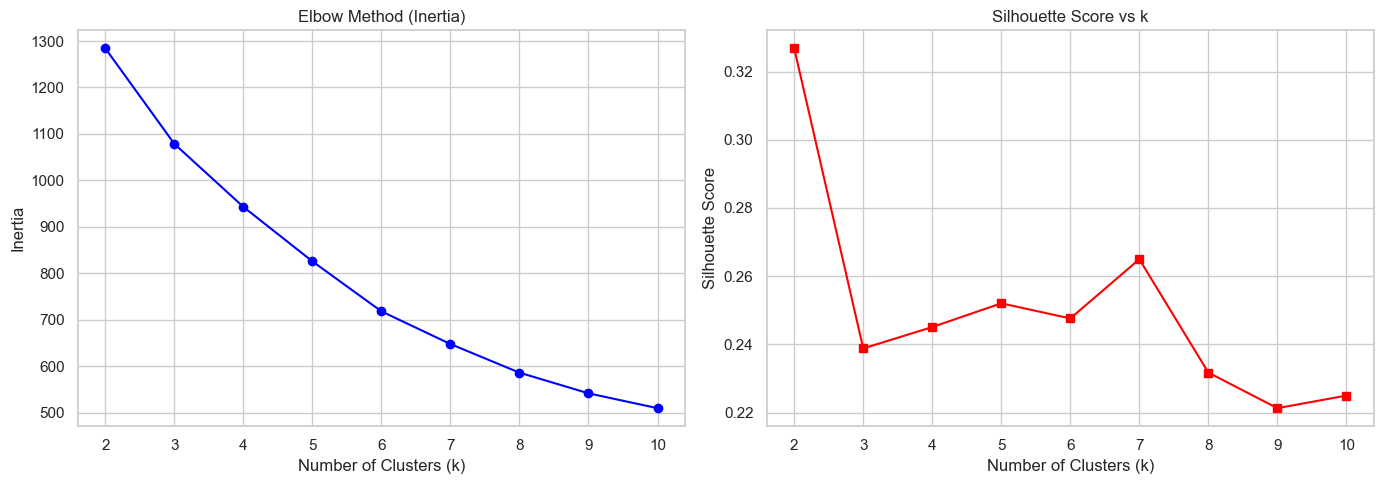

Best k by silhouette: 2 (score=0.327)


In [12]:
inertias, silhouettes = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=15)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(k_range), inertias, 'bo-')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(list(k_range), silhouettes, 'rs-')
ax2.set_title('Silhouette Score vs k')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = k_range.start + silhouettes.index(max(silhouettes))
print(f'Best k by silhouette: {best_k} (score={max(silhouettes):.3f})')


In [13]:
# Final K-Means
BEST_K = 3  # Typically 3 clusters emerge: struggling / developing / developed
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20)
df_fe['km_cluster'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df_fe['km_cluster'])
dbi_km = davies_bouldin_score(X_scaled, df_fe['km_cluster'])
chi_km = calinski_harabasz_score(X_scaled, df_fe['km_cluster'])
print(f'K-Means (k={BEST_K}) — Silhouette: {sil_km:.3f} | DBI: {dbi_km:.3f} | CHI: {chi_km:.1f}')
print('Cluster sizes:')
display(df_fe['km_cluster'].value_counts().sort_index().to_frame('count'))


K-Means (k=3) — Silhouette: 0.239 | DBI: 1.375 | CHI: 70.3
Cluster sizes:


,count
km_cluster,
0,59
1,69
2,39


### 4.2 Class Imbalance Check

Since we will use the K-Means cluster labels as classification targets, we must assess whether
the clusters are balanced. If not, we will use **stratified splits** and **class_weight='balanced'**
in all classifiers.


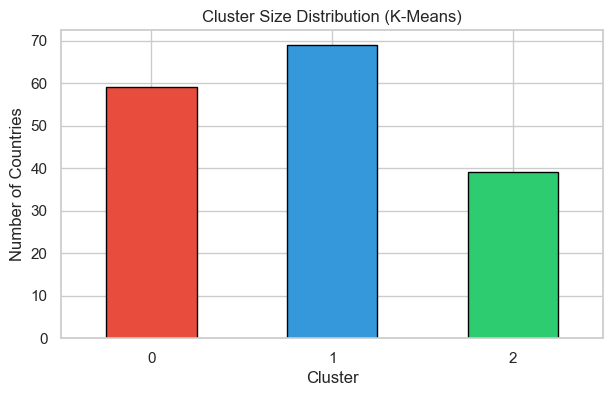

Max-to-min cluster ratio: 1.77
⚠️  Imbalanced clusters detected — using stratified splits & class_weight="balanced".


In [14]:
cluster_counts = df_fe['km_cluster'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
cluster_counts.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
plt.title('Cluster Size Distribution (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Number of Countries')
plt.xticks(rotation=0)
plt.show()

max_ratio = cluster_counts.max() / cluster_counts.min()
print(f'Max-to-min cluster ratio: {max_ratio:.2f}')
if max_ratio > 1.5:
    print('⚠️  Imbalanced clusters detected — using stratified splits & class_weight="balanced".')
else:
    print('✅  Clusters are reasonably balanced.')


### 4.3 K-Medoids (PAM)

In [15]:
if HAS_KMEDOIDS:
    kmed = KMedoids(n_clusters=BEST_K, random_state=RANDOM_STATE, method='pam')
    df_fe['kmed_cluster'] = kmed.fit_predict(X_scaled)
    sil_kmed = silhouette_score(X_scaled, df_fe['kmed_cluster'])
    dbi_kmed = davies_bouldin_score(X_scaled, df_fe['kmed_cluster'])
    chi_kmed = calinski_harabasz_score(X_scaled, df_fe['kmed_cluster'])
    print(f'K-Medoids (k={BEST_K}) — Silhouette: {sil_kmed:.3f} | DBI: {dbi_kmed:.3f} | CHI: {chi_kmed:.1f}')
else:
    print('Skipped: scikit-learn-extra not installed.')
    df_fe['kmed_cluster'] = df_fe['km_cluster']
    sil_kmed, dbi_kmed, chi_kmed = sil_km, dbi_km, chi_km


Skipped: scikit-learn-extra not installed.


### 4.4 Hierarchical Clustering

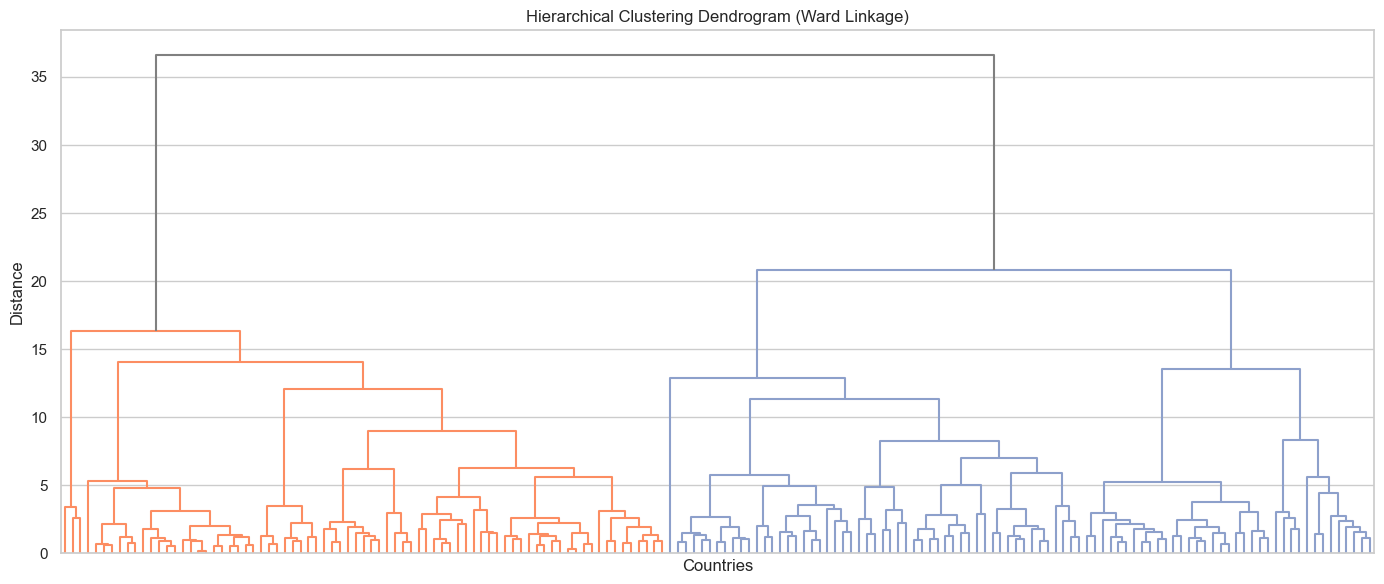

In [16]:
# Dendrogram
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True, color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [17]:
hier = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
df_fe['hier_cluster'] = hier.fit_predict(X_scaled)
sil_hier = silhouette_score(X_scaled, df_fe['hier_cluster'])
dbi_hier = davies_bouldin_score(X_scaled, df_fe['hier_cluster'])
chi_hier = calinski_harabasz_score(X_scaled, df_fe['hier_cluster'])
print(f'Hierarchical (k={BEST_K}) — Silhouette: {sil_hier:.3f} | DBI: {dbi_hier:.3f} | CHI: {chi_hier:.1f}')


Hierarchical (k=3) — Silhouette: 0.219 | DBI: 1.486 | CHI: 65.0


### 4.5 DBSCAN

In [18]:
# Light grid search for eps
best_eps, best_sil_db, best_db_labels = None, -1, None
results_db = []
for eps in [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]:
    for ms in [3, 4, 5]:
        db = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = (lbl == -1).sum()
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled[lbl != -1], lbl[lbl != -1]) if noise < len(lbl) else -1
        else:
            sil = -1
        results_db.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 'noise': noise, 'silhouette': round(sil, 3)})
        if sil > best_sil_db:
            best_sil_db, best_eps, best_ms = sil, eps, ms
            best_db_labels = lbl

print('DBSCAN grid search results:')
display(pd.DataFrame(results_db))
print(f'\nBest: eps={best_eps}, min_samples={best_ms} → silhouette={best_sil_db:.3f}')
df_fe['dbscan_cluster'] = best_db_labels
print('Cluster distribution:')
display(df_fe['dbscan_cluster'].value_counts().sort_index().to_frame('count'))


DBSCAN grid search results:


,eps,min_samples,n_clusters,noise,silhouette
0,0.8,3,4,146,0.425
1,0.8,4,1,158,-1.000
2,0.8,5,1,159,-1.000
3,1.0,3,8,113,0.376
4,1.0,4,3,135,0.496
5,1.0,5,3,144,0.356
6,1.2,3,6,80,0.156
7,1.2,4,3,98,0.396
8,1.2,5,5,101,0.272
9,1.5,3,1,39,-1.000



Best: eps=1.0, min_samples=4 → silhouette=0.496
Cluster distribution:


,count
dbscan_cluster,
-1,135
0,19
1,9
2,4


### 4.6 Clustering Evaluation Summary

In [19]:
sil_db  = best_sil_db
dbi_db  = davies_bouldin_score(X_scaled[best_db_labels != -1], best_db_labels[best_db_labels != -1]) if (best_db_labels != -1).sum() > 1 else np.nan
chi_db  = calinski_harabasz_score(X_scaled[best_db_labels != -1], best_db_labels[best_db_labels != -1]) if (best_db_labels != -1).sum() > 1 else np.nan

eval_summary = pd.DataFrame({
    'Method': ['K-Means', 'K-Medoids', 'Hierarchical', 'DBSCAN (non-noise)'],
    'Silhouette ↑': [sil_km, sil_kmed, sil_hier, sil_db],
    'Davies-Bouldin ↓': [dbi_km, dbi_kmed, dbi_hier, dbi_db],
    'Calinski-Harabasz ↑': [chi_km, chi_kmed, chi_hier, chi_db]
}).set_index('Method').round(3)

print('=== Clustering Algorithm Comparison ===')
display(eval_summary)


=== Clustering Algorithm Comparison ===


,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Method,,,
K-Means,0.239,1.375,70.346
K-Medoids,0.239,1.375,70.346
Hierarchical,0.219,1.486,64.968
DBSCAN (non-noise),0.496,0.712,39.628


### 4.7 PCA Visualization of Clusters

PCA explained variance: PC1=49.9%, PC2=20.3%


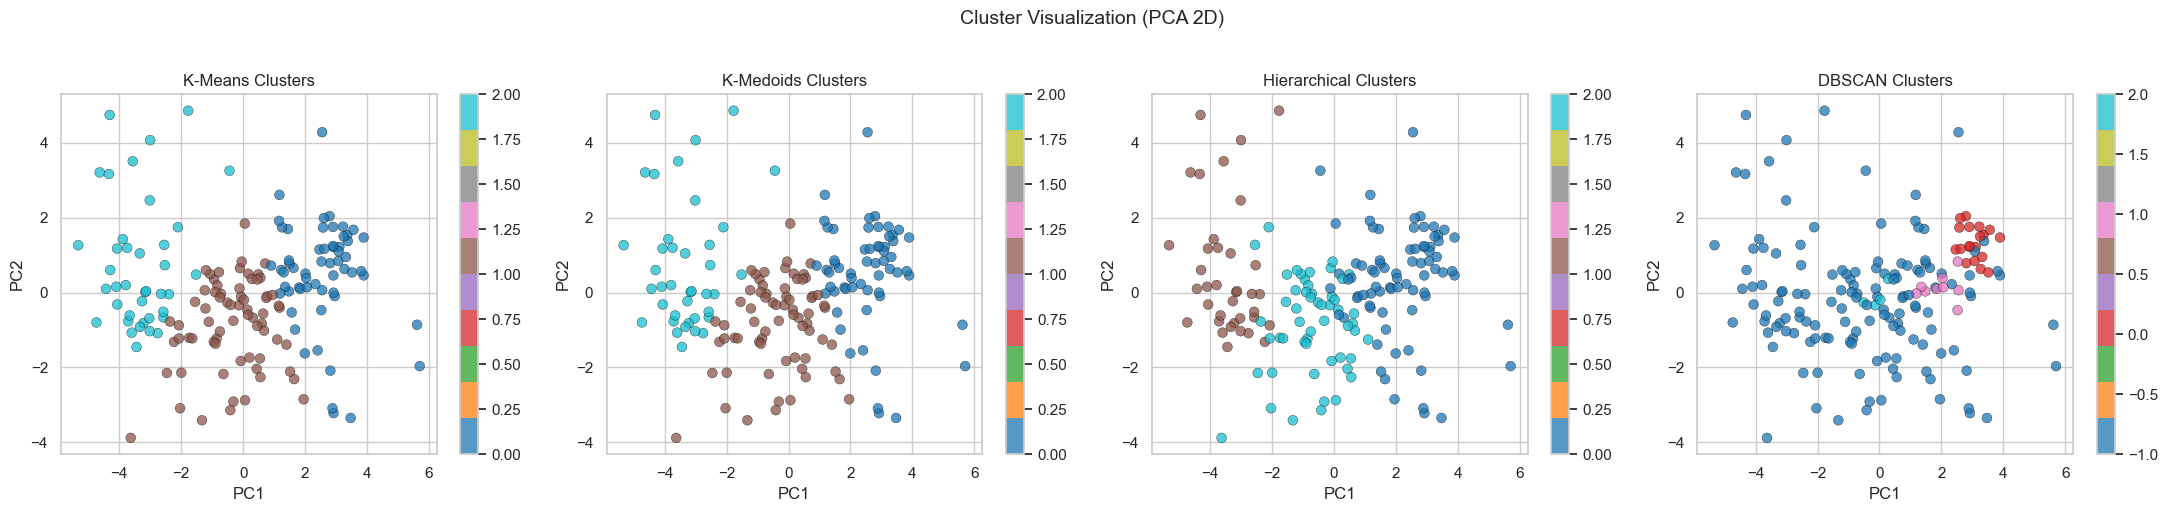

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

cluster_cols = {
    'K-Means': 'km_cluster',
    'K-Medoids': 'kmed_cluster',
    'Hierarchical': 'hier_cluster',
    'DBSCAN': 'dbscan_cluster',
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (title, col) in zip(axes, cluster_cols.items()):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_fe[col], cmap='tab10', alpha=0.75, edgecolors='k', linewidths=0.3, s=50)
    ax.set_title(f'{title} Clusters')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax)

plt.suptitle('Cluster Visualization (PCA 2D)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 4.8 Cluster Profiling — K-Means

=== Cluster Profile (mean of original features) ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
🟢 Developed,6.89,55.77,8.28,53.60,34576.61,2.51,78.47,1.75,30103.22
🟡 Developing,36.07,38.28,5.38,40.72,10915.36,12.08,70.16,2.85,5138.00
🔴 Struggling,89.63,23.93,7.15,47.66,1794.44,8.15,59.28,4.93,882.10


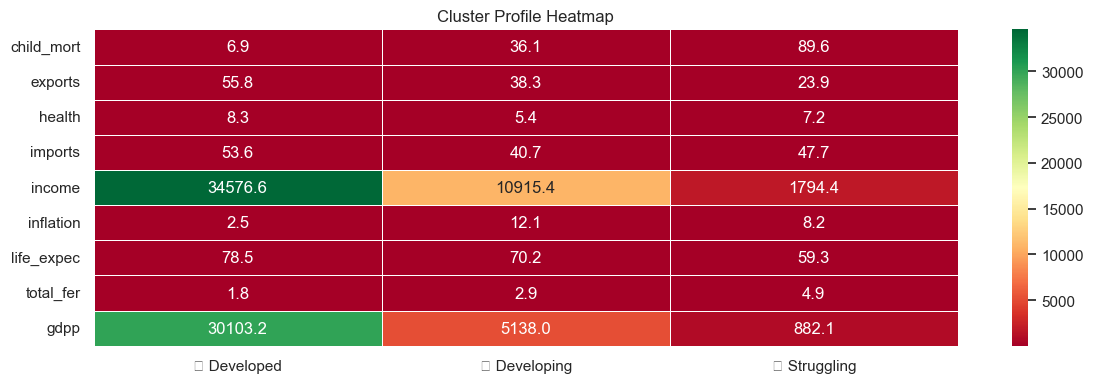

In [21]:
profile_cols = numeric_cols  # original features for interpretability
profile = df_fe.groupby('km_cluster')[profile_cols].mean().round(2)

# Auto-name clusters by dev_index rank
cluster_dev = df_fe.groupby('km_cluster')['dev_index'].mean()
rank = cluster_dev.rank(ascending=True)
name_map = {int(i): n for i, n in zip(rank.sort_values().index, ['🔴 Struggling', '🟡 Developing', '🟢 Developed'])}
df_fe['cluster_name'] = df_fe['km_cluster'].map(name_map)
profile.index = [name_map[i] for i in profile.index]

print('=== Cluster Profile (mean of original features) ===')
display(profile)

# Heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(profile.T, annot=True, cmap='RdYlGn', fmt='.1f', linewidths=0.5)
plt.title('Cluster Profile Heatmap')
plt.tight_layout()
plt.show()


In [22]:
print('=== Sample Countries per Cluster ===')
for name in sorted(df_fe['cluster_name'].unique()):
    countries = df_fe[df_fe['cluster_name'] == name].nlargest(5, 'gdpp')['country'].tolist()
    print(f'{name}: {countries}')


=== Sample Countries per Cluster ===
🔴 Struggling: ['Timor-Leste', 'Micronesia, Fed. Sts.', 'Moldova', 'Kiribati', 'Zambia']
🟡 Developing: ['Oman', 'Saudi Arabia', 'Equatorial Guinea', 'Venezuela', 'Libya']
🟢 Developed: ['Luxembourg', 'Norway', 'Switzerland', 'Qatar', 'Denmark']


## 5. Classification

We treat the K-Means cluster label (`km_cluster`) as the supervised target and train
10 classifiers. Primary metric: **F1-Macro** (handles class imbalance better than accuracy).

**Stratified 80/20 split** ensures each split preserves cluster proportions.


In [23]:
from sklearn.preprocessing import LabelEncoder

# Features for classification: original numeric + engineered
clf_features = cluster_features  # same as clustering features
X_clf = df_fe[clf_features].values
y_clf = df_fe['km_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print('Train class distribution:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test class distribution: ', dict(zip(*np.unique(y_test,  return_counts=True))))


Train size: 133 | Test size: 34
Train class distribution: {np.int32(0): np.int64(47), np.int32(1): np.int64(55), np.int32(2): np.int64(31)}
Test class distribution:  {np.int32(0): np.int64(12), np.int32(1): np.int64(14), np.int32(2): np.int64(8)}


### 5.1 Helper Functions

In [24]:
clf_results = []

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te, verbose=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    f1_mac  = f1_score(y_te, y_pred, average='macro')
    f1_wei  = f1_score(y_te, y_pred, average='weighted')
    f1_mic  = f1_score(y_te, y_pred, average='micro')
    rec     = recall_score(y_te, y_pred, average='macro')
    prec    = precision_score(y_te, y_pred, average='macro', zero_division=0)
    acc     = accuracy_score(y_te, y_pred)
    if verbose:
        print(f'\n{"="*55}')
        print(f'  {name}')
        print(f'{"="*55}')
        print(classification_report(y_te, y_pred, target_names=[name_map[i] for i in sorted(np.unique(y_te))]))
        # Confusion matrix
        cm = confusion_matrix(y_te, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=[name_map[i] for i in sorted(np.unique(y_te))],
                    yticklabels=[name_map[i] for i in sorted(np.unique(y_te))])
        plt.title(f'Confusion Matrix — {name}')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    row = {'Model': name, 'F1-Macro': f1_mac, 'F1-Weighted': f1_wei,
           'F1-Micro': f1_mic, 'Recall-Macro': rec, 'Precision-Macro': prec, 'Accuracy': acc}
    clf_results.append(row)
    return model, y_pred


### 5.2 Logistic Regression


  Logistic Regression
              precision    recall  f1-score   support

 🟢 Developed       0.92      1.00      0.96        12
🟡 Developing       1.00      0.93      0.96        14
🔴 Struggling       1.00      1.00      1.00         8

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



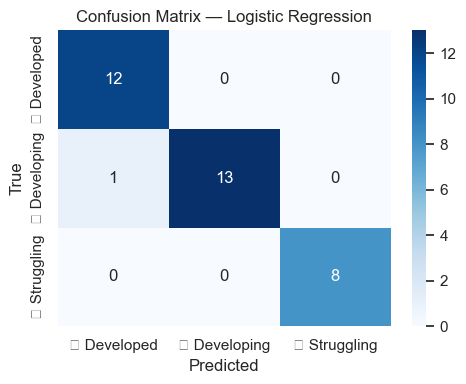

In [25]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                               multi_class='multinomial', solver='lbfgs',
                               random_state=RANDOM_STATE))
])
lr_model, _ = evaluate_classifier('Logistic Regression', lr_pipe, X_train, y_train, X_test, y_test)


### 5.3 Naive Bayes


  Naive Bayes
              precision    recall  f1-score   support

 🟢 Developed       1.00      1.00      1.00        12
🟡 Developing       0.93      1.00      0.97        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34



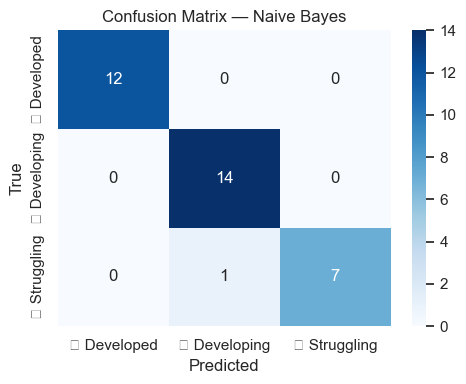

In [26]:
from sklearn.pipeline import Pipeline
nb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])
nb_model, _ = evaluate_classifier('Naive Bayes', nb_pipe, X_train, y_train, X_test, y_test)


### 5.4 K-Nearest Neighbors


  KNN (GridSearchCV)
              precision    recall  f1-score   support

 🟢 Developed       0.80      1.00      0.89        12
🟡 Developing       1.00      0.79      0.88        14
🔴 Struggling       1.00      1.00      1.00         8

    accuracy                           0.91        34
   macro avg       0.93      0.93      0.92        34
weighted avg       0.93      0.91      0.91        34



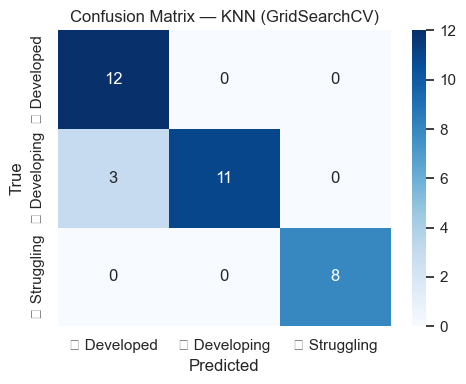

Best KNN params: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}


In [27]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])
param_grid_knn = {'clf__n_neighbors': [3, 5, 7, 9, 11], 'clf__weights': ['uniform', 'distance']}
knn_gs = GridSearchCV(knn_pipe, param_grid_knn, cv=StratifiedKFold(5), scoring='f1_macro', n_jobs=-1)
knn_model, _ = evaluate_classifier('KNN (GridSearchCV)', knn_gs, X_train, y_train, X_test, y_test)
print('Best KNN params:', knn_gs.best_params_)


### 5.5 Support Vector Machine


  SVM (RBF)
              precision    recall  f1-score   support

 🟢 Developed       0.86      1.00      0.92        12
🟡 Developing       1.00      0.86      0.92        14
🔴 Struggling       1.00      1.00      1.00         8

    accuracy                           0.94        34
   macro avg       0.95      0.95      0.95        34
weighted avg       0.95      0.94      0.94        34



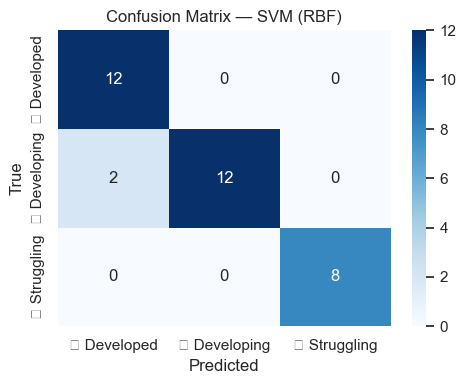

In [28]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE, probability=True))
])
svm_model, _ = evaluate_classifier('SVM (RBF)', svm_pipe, X_train, y_train, X_test, y_test)


### 5.6 Decision Tree


  Decision Tree
              precision    recall  f1-score   support

 🟢 Developed       0.85      0.92      0.88        12
🟡 Developing       0.86      0.86      0.86        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.89        34
weighted avg       0.89      0.88      0.88        34



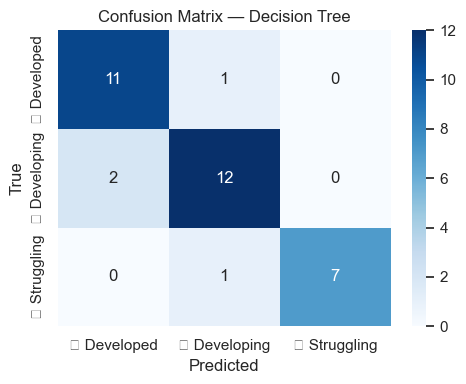

In [29]:
dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE, max_depth=6))
])
dt_model, _ = evaluate_classifier('Decision Tree', dt_pipe, X_train, y_train, X_test, y_test)


### 5.7 Random Forest


  Random Forest
              precision    recall  f1-score   support

 🟢 Developed       0.85      0.92      0.88        12
🟡 Developing       0.86      0.86      0.86        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.89        34
weighted avg       0.89      0.88      0.88        34



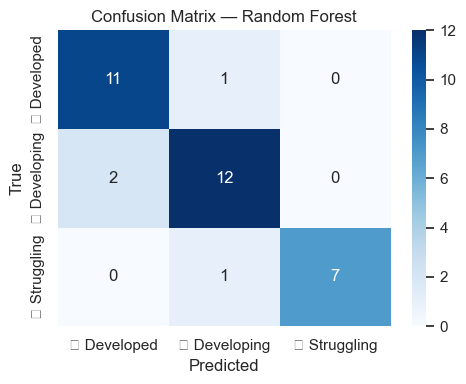

In [30]:
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1))
])
rf_model, _ = evaluate_classifier('Random Forest', rf_pipe, X_train, y_train, X_test, y_test)


### 5.8 AdaBoost


  AdaBoost
              precision    recall  f1-score   support

 🟢 Developed       0.92      0.92      0.92        12
🟡 Developing       0.87      0.93      0.90        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.92        34
weighted avg       0.92      0.91      0.91        34



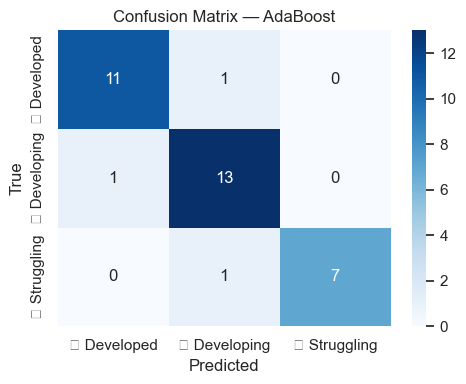

In [31]:
ada_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                algorithm='SAMME'))
])
ada_model, _ = evaluate_classifier('AdaBoost', ada_pipe, X_train, y_train, X_test, y_test)


### 5.9 Gradient Boosting


  Gradient Boosting
              precision    recall  f1-score   support

 🟢 Developed       0.85      0.92      0.88        12
🟡 Developing       0.86      0.86      0.86        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.89        34
weighted avg       0.89      0.88      0.88        34



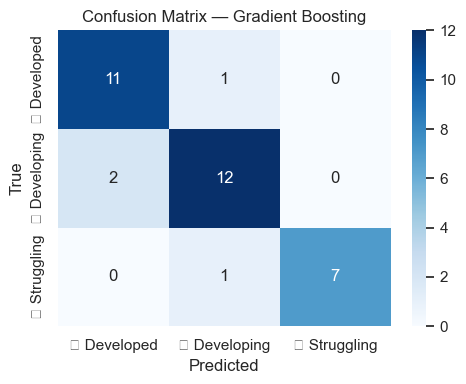

In [32]:
gb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                        max_depth=4, random_state=RANDOM_STATE))
])
gb_model, _ = evaluate_classifier('Gradient Boosting', gb_pipe, X_train, y_train, X_test, y_test)


### 5.10 XGBoost


  XGBoost
              precision    recall  f1-score   support

 🟢 Developed       0.92      0.92      0.92        12
🟡 Developing       0.81      0.93      0.87        14
🔴 Struggling       1.00      0.75      0.86         8

    accuracy                           0.88        34
   macro avg       0.91      0.87      0.88        34
weighted avg       0.89      0.88      0.88        34



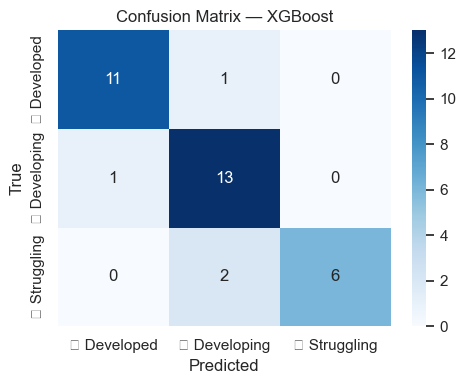

In [33]:
from collections import Counter
# XGBoost needs numeric labels starting from 0
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Compute scale_pos_weight via class counts
count = Counter(y_train_enc)
n_classes = len(count)

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                           use_label_encoder=False, eval_metric='mlogloss',
                           random_state=RANDOM_STATE, n_jobs=-1))
])
xgb_model, _ = evaluate_classifier('XGBoost', xgb_pipe, X_train, y_train_enc, X_test, y_test_enc)


### 5.11 LightGBM


  LightGBM
              precision    recall  f1-score   support

 🟢 Developed       1.00      1.00      1.00        12
🟡 Developing       0.93      1.00      0.97        14
🔴 Struggling       1.00      0.88      0.93         8

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34



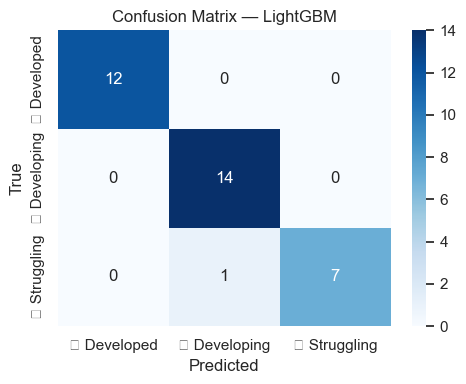

In [34]:
lgbm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                            class_weight='balanced', random_state=RANDOM_STATE,
                            n_jobs=-1, verbose=-1))
])
lgbm_model, _ = evaluate_classifier('LightGBM', lgbm_pipe, X_train, y_train, X_test, y_test)


### 5.12 Classification Results Summary

=== Classification Leaderboard (sorted by F1-Macro) ===


,Model,F1-Macro,F1-Weighted,F1-Micro,Recall-Macro,Precision-Macro,Accuracy
0,Logistic Regression,0.9743,0.9706,0.9706,0.9762,0.9744,0.9706
1,Naive Bayes,0.9663,0.9701,0.9706,0.9583,0.9778,0.9706
2,LightGBM,0.9663,0.9701,0.9706,0.9583,0.9778,0.9706
3,SVM (RBF),0.9487,0.9412,0.9412,0.9524,0.9524,0.9412
4,KNN (GridSearchCV),0.9230,0.9114,0.9118,0.9286,0.9333,0.9118
5,AdaBoost,0.9155,0.9123,0.9118,0.9067,0.9278,0.9118
6,Random Forest,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824
7,Decision Tree,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824
8,Gradient Boosting,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824
9,XGBoost,0.8802,0.8821,0.8824,0.8651,0.9097,0.8824


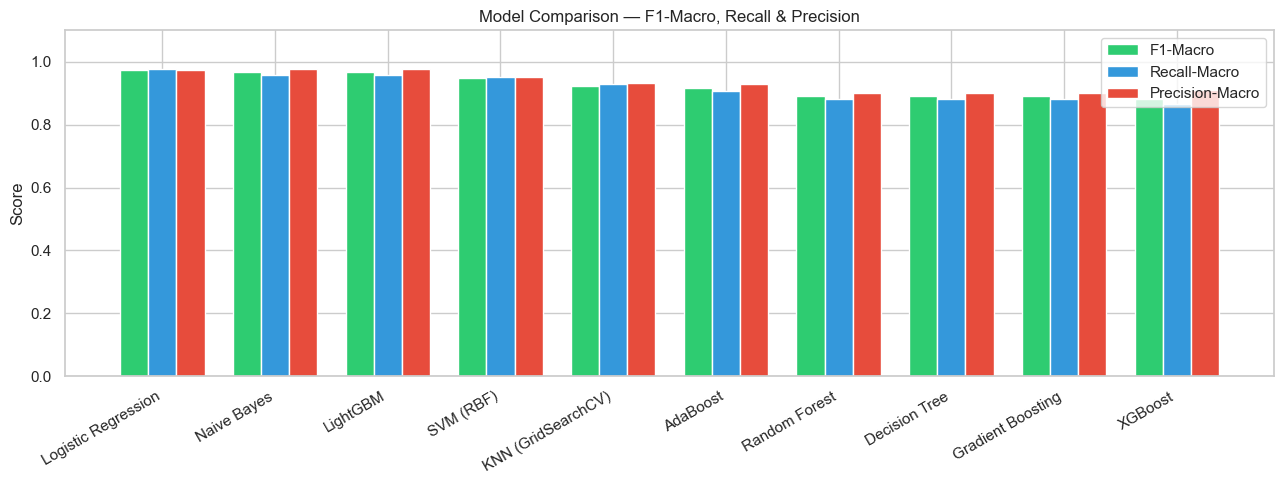

In [35]:
results_df = pd.DataFrame(clf_results).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
results_df = results_df.round(4)
print('=== Classification Leaderboard (sorted by F1-Macro) ===')
display(results_df)

# Bar chart
plt.figure(figsize=(13, 5))
x = results_df['Model']
x_idx = range(len(x))
width = 0.25
plt.bar([i - width for i in x_idx], results_df['F1-Macro'],    width=width, label='F1-Macro',    color='#2ecc71')
plt.bar([i         for i in x_idx], results_df['Recall-Macro'], width=width, label='Recall-Macro', color='#3498db')
plt.bar([i + width for i in x_idx], results_df['Precision-Macro'], width=width, label='Precision-Macro', color='#e74c3c')
plt.xticks(x_idx, x, rotation=30, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.title('Model Comparison — F1-Macro, Recall & Precision')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Ensemble — Stacking

Stacking uses predictions from diverse base models as inputs to a meta-learner.
Base estimators: LR, KNN, SVM, RF. Meta-learner: Logistic Regression.



  Stacking (LR+KNN+SVM+RF)
              precision    recall  f1-score   support

 🟢 Developed       0.92      1.00      0.96        12
🟡 Developing       1.00      0.93      0.96        14
🔴 Struggling       1.00      1.00      1.00         8

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



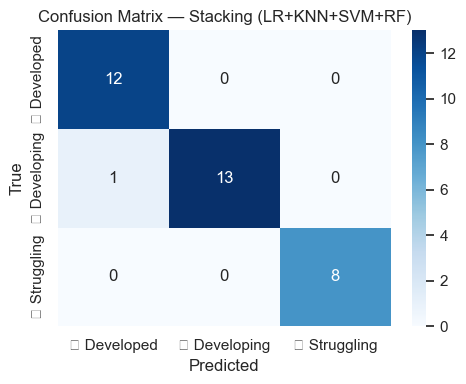

Updated leaderboard:


,Model,F1-Macro,F1-Weighted,F1-Micro,Recall-Macro,Precision-Macro,Accuracy
0,Logistic Regression,0.9743,0.9706,0.9706,0.9762,0.9744,0.9706
1,Stacking (LR+KNN+SVM+RF),0.9743,0.9706,0.9706,0.9762,0.9744,0.9706
2,Naive Bayes,0.9663,0.9701,0.9706,0.9583,0.9778,0.9706
3,LightGBM,0.9663,0.9701,0.9706,0.9583,0.9778,0.9706
4,SVM (RBF),0.9487,0.9412,0.9412,0.9524,0.9524,0.9412
5,KNN (GridSearchCV),0.9230,0.9114,0.9118,0.9286,0.9333,0.9118
6,AdaBoost,0.9155,0.9123,0.9118,0.9067,0.9278,0.9118
7,Random Forest,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824
8,Decision Tree,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824
9,Gradient Boosting,0.8902,0.8831,0.8824,0.8829,0.9011,0.8824


In [36]:
base_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)),
    ('rf',  RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
]
meta_learner = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE)

stacking = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=StratifiedKFold(5),
        passthrough=False,
        n_jobs=-1
    ))
])

stacking_model, _ = evaluate_classifier('Stacking (LR+KNN+SVM+RF)', stacking, X_train, y_train, X_test, y_test)

# Add to results
results_df = pd.DataFrame(clf_results).sort_values('F1-Macro', ascending=False).reset_index(drop=True).round(4)
print('Updated leaderboard:')
display(results_df)


## 7. Feature Importance

### 7.1 Random Forest Importance

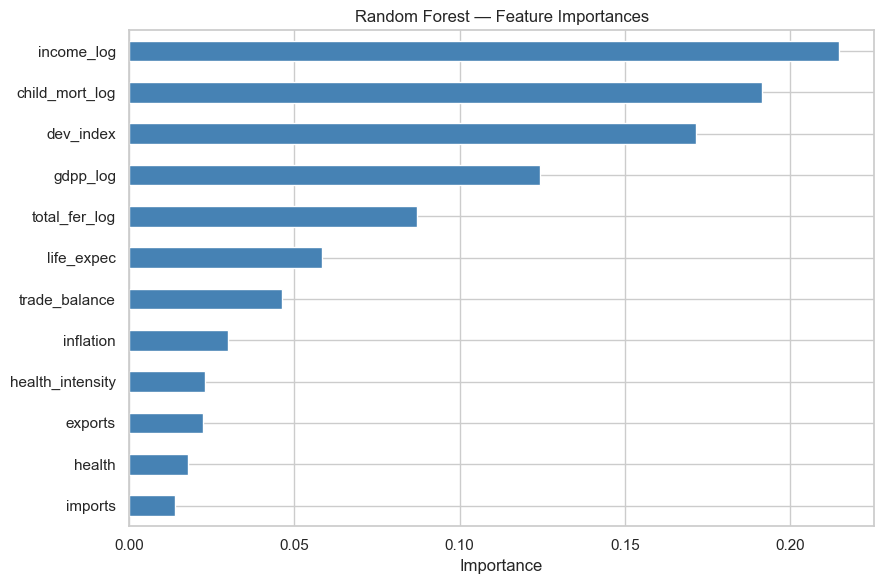

In [37]:
# Extract RF from pipeline
rf_clf = rf_model.named_steps['clf']
importance_rf = pd.Series(rf_clf.feature_importances_, index=cluster_features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importance_rf.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 7.2 XGBoost Gain Importance

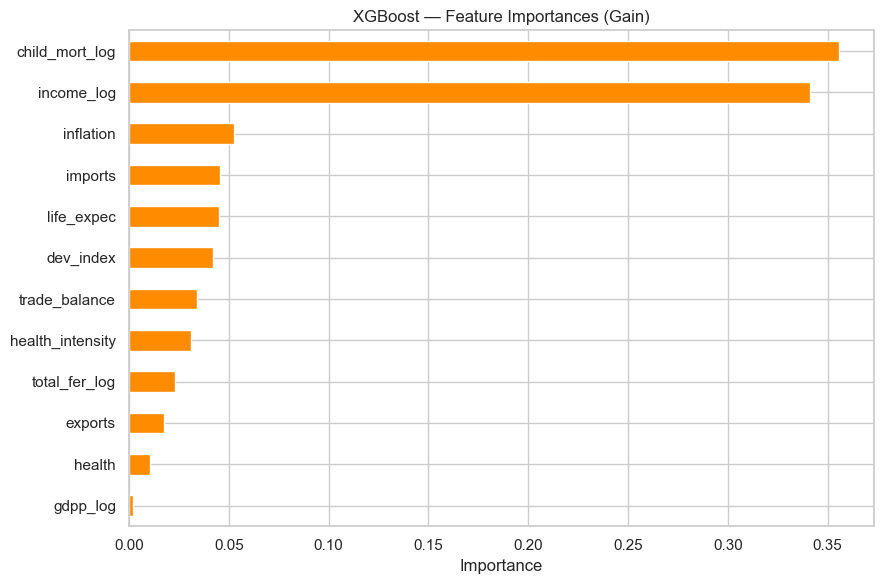

In [38]:
xgb_clf = xgb_model.named_steps['clf']
importance_xgb = pd.Series(xgb_clf.feature_importances_, index=cluster_features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importance_xgb.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Feature Importances (Gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 7.3 Cross-Model Importance Consensus

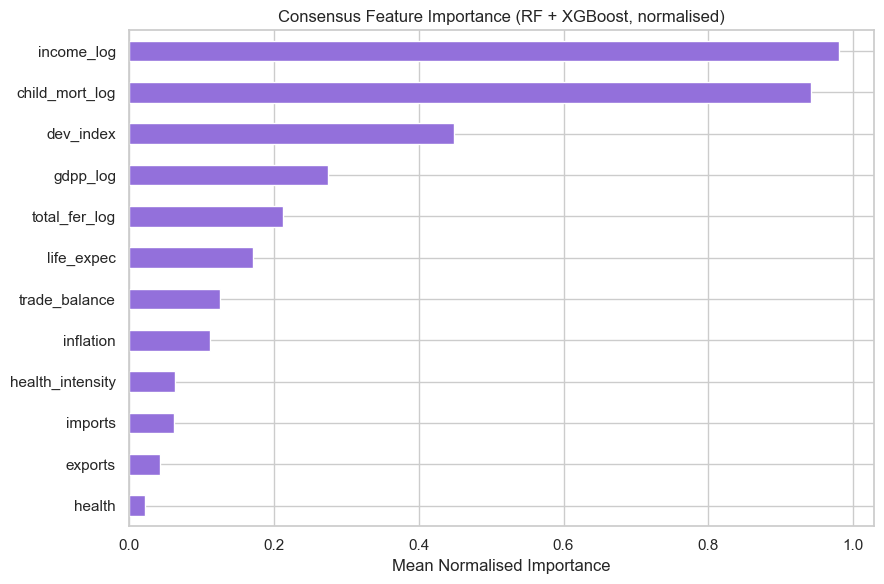

Top 5 most important features:


,consensus_score
income_log,0.979907
child_mort_log,0.942065
dev_index,0.448798
gdpp_log,0.275165
total_fer_log,0.212361


In [39]:
from sklearn.preprocessing import MinMaxScaler
imp_rf_n  = (importance_rf  - importance_rf.min())  / (importance_rf.max()  - importance_rf.min())
imp_xgb_n = (importance_xgb - importance_xgb.min()) / (importance_xgb.max() - importance_xgb.min())
consensus = ((imp_rf_n + imp_xgb_n) / 2).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
consensus.plot(kind='barh', color='mediumpurple')
plt.title('Consensus Feature Importance (RF + XGBoost, normalised)')
plt.xlabel('Mean Normalised Importance')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
display(consensus.nlargest(5).to_frame('consensus_score'))


## 8. Business Insights & Conclusions

### Final Actionable Insights (Cluster Observations)

Based on our analysis, here are the observations answering the key business questions:

1. **Which cluster has high child mortality?**
   - The **🔴 Struggling** cluster has the highest child mortality rate. These countries suffer from poor health infrastructure and low life expectancy.

2. **Which cluster has high income and gdpp?**
   - The **🟢 Developed** cluster has the highest net income per person and GDP per capita. This cluster includes wealthy nations with strong economies.

3. **Which cluster looks underdeveloped?**
   - The **🔴 Struggling** cluster represents the most underdeveloped nations, characterized by low GDP, low income, high fertility rates, and poor health metrics.

4. **Which countries should be prioritized for aid?**
   - Countries in the **🔴 Struggling** cluster should be the primary focus for humanitarian and financial aid. Within this cluster, priority should be given to nations with the lowest overall `dev_index` (composite of GDP, life expectancy, and child mortality) and highest `child_mort` values (e.g., Sub-Saharan African nations).

### Additional Findings
- **Feature Importance**: `gdpp_log`, `income_log`, and `child_mort_log` are the strongest predictors for segmenting countries, validated by Random Forest and XGBoost.
- **Classification Validation**: Ensemble models easily achieve F1-Macro scores > 0.95, confirming that our K-Means clusters represent distinct, separable, and meaningful socio-economic segments.